In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer, DataCollatorForSeq2Seq
from datasets import load_dataset
import numpy as np
import math
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt

In [2]:
class LoRALayer(nn.Module):
    def __init__(
        self, 
        original_layer, 
        rank=8, 
        alpha=16, 
        dropout=0.05
    ):
        super().__init__()
        self.original_layer = original_layer
        self.dtype = next(original_layer.parameters()).dtype
        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank
        
        # Freezing original layer
        for param in self.original_layer.parameters():
            param.requires_grad = False
            
        in_dim = original_layer.in_features
        out_dim = original_layer.out_features
        
        # LoRA A: Kaiming Uniform, B: Zeros
        self.lora_A = nn.Parameter(torch.zeros(rank, in_dim, dtype=self.dtype))
        self.lora_B = nn.Parameter(torch.zeros(out_dim, rank, dtype=self.dtype))
        self.dropout = nn.Dropout(dropout)
        
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)

    def forward(self, x):
        original_out = self.original_layer(x)
        # B @ A @ x
        lora_out = (self.dropout(x) @ self.lora_A.T @ self.lora_B.T) * self.scaling
        return original_out + lora_out

    def get_stable_rank(self):
        """Calculates Stable Rank of the update matrix (BA)."""
        with torch.no_grad():
            W_delta = (self.lora_B @ self.lora_A * self.scaling).to(torch.float32)
            
            # Frobenius Norm
            frob_norm = torch.norm(W_delta, p='fro')
            # try:
            S = torch.linalg.svdvals(W_delta)
            spectral_norm = S[0]
            # except:
                # print("FAILED TO GET SVDVALS FOR SPECTRAL NORM")
                # return 1.0 # Fallback
            
            if spectral_norm == 0:
                print("SPECTRAL NORM IS 0. UNEXPECTED BEHAVIOUR")
                return 1.0
                
            stable_rank = (frob_norm ** 2) / (spectral_norm ** 2)
            return stable_rank.item()

def inject_lora(
    model, 
    target_suffixes=["gate_proj", "up_proj", "down_proj"], 
    rank=16, 
    alpha=32
):
    """
    Injects LoRA layers into the model by replacing specific nn.Linear modules.
    
    Args:
        target_suffixes: List of strings. If a module's name ends with one of these,
                         it is replaced. Default is FFN only: ['gate_proj', 'up_proj', 'down_proj'].
                         To include Attention, add: ['q_proj', 'k_proj', 'v_proj', 'o_proj'].
    """
        
    print(f"Injecting LoRA for targets ending in: {target_suffixes}")
    
    modules_to_replace = []
    
    for name, module in model.named_modules():
        # check if this module matches any target suffix
        if isinstance(module, nn.Linear) and any(name.endswith(suffix) for suffix in target_suffixes):
            modules_to_replace.append(name)

    # Perform replacement
    replaced_count = 0
    for full_name in modules_to_replace:
        # Split into parent path and child name
        parent_name, child_name = full_name.rsplit('.', 1)
        
        # Retrieve parent module
        parent = model.get_submodule(parent_name)
        original_module = getattr(parent, child_name)
        
        # Create and swap
        lora_layer = LoRALayer(original_module, rank=rank, alpha=alpha)
        setattr(parent, child_name, lora_layer)
        replaced_count += 1
        
    print(f"Successfully replaced {replaced_count} layers with LoRA.")
    return model

In [3]:
def prepare_data(tokenizer, num_samples=10000):
    # Dataset: b-mc2/sql-create-context
    # Columns: question, context (CREATE TABLE ...), answer (SQL)
    dataset = load_dataset("b-mc2/sql-create-context", split="train")
    
    # Subsample
    if len(dataset) > num_samples:
        dataset = dataset.select(range(num_samples))
        
    def format_sql_task(example):
        # Construct a clear Instruct prompt
        # The model must use the schema in 'context' to answer 'question'
        prompt = (
            f'''<|im_start|>system
            You are a SQL expert. Convert the question into a SQL query based on the provided schema.<|im_end|>
            <|im_start|>user
            {example['context']}\n\nQuestion: {example['question']}<|im_end|>
            <|im_start|>assistant
            {example['answer']}<|im_end|>'''
        )
        return tokenizer(prompt, max_length=512, truncation=True, padding="max_length")
    
    dataset = dataset.map(format_sql_task)
    dataset.set_format("torch", columns=["input_ids", "attention_mask"])
    
    split = dataset.train_test_split(test_size=0.025)
    return split["train"], split["test"]

In [4]:
def evaluate(model, loader, device, tokenizer):
    model.eval()
    losses = []
    srs = []
    
    # Loss Loop
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = input_ids.clone()
            labels[labels == tokenizer.pad_token_id] = -100 # Ignore padding
            
            out = model(input_ids, attention_mask=mask, labels=labels)
            losses.append(out.loss.item())
            
    # Stable Rank Loop
    for m in model.modules():
        if isinstance(m, LoRALayer):
            srs.append(m.get_stable_rank())
    if srs:
        return np.mean(losses), np.mean(srs), srs
    else:
        return np.mean(losses), 0.0, []

In [ ]:
def run_experiment(
    model_id="Qwen/Qwen2.5-0.5B",
    num_samples=5000,
    lr=2e-4,
    epochs=1,
    batch_size=4,
    rank=16,
    target_suffixes=["gate_proj", "up_proj", "down_proj"],
    report_to=None,
    eval_steps=50
):
    # Config
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Device: {device}")
    
    # Load
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.bfloat16).to(device)
    
    # Inject LoRA (Default: FFN only)
    # To add Attention: target_suffixes=["gate_proj", "up_proj", "down_proj", "q_proj", "v_proj"]
    if target_suffixes: 
        for p in model.parameters():
            p.requires_grad = False
        inject_lora(
            model, 
            rank=rank, 
            target_suffixes=target_suffixes
        )
    model.to(device)
    
    # Data
    train_ds, val_ds = prepare_data(tokenizer, num_samples=num_samples)
    collator = DataCollatorForSeq2Seq(tokenizer, pad_to_multiple_of=8, return_tensors="pt", padding=True)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collator)
    val_loader = DataLoader(val_ds, batch_size=batch_size, collate_fn=collator)
    
    # Optimizer
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=lr)
    
    # Logging
    writer = SummaryWriter(log_dir="runs/sql_lora") if report_to == "tensorboard" else None
    
    # Training
    print("Starting SQL Finetuning...")
    loss_history = []
    sr_history = []
    global_step = 0
    
    model.train()
    for epoch in range(epochs):
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        for batch in pbar:
            input_ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = input_ids.clone()
            labels[labels == tokenizer.pad_token_id] = -100
            
            out = model(input_ids, attention_mask=mask, labels=labels)
            loss = out.loss
            
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            
            global_step += 1
            
            if global_step % eval_steps == 0:
                val_loss, val_sr, _ = evaluate(model, val_loader, device, tokenizer)
                loss_history.append(val_loss)
                sr_history.append(val_sr)
                
                model.train()
                pbar.set_postfix({"Val Loss": f"{val_loss:.3f}", "Avg SR": f"{val_sr:.2f}"})
                
                if writer:
                    writer.add_scalar("Loss/Val", val_loss, global_step)
                    writer.add_scalar("StableRank/Avg", val_sr, global_step)

    print(f"Final Average Stable Rank: {sr_history[-1]:.3f}")
    
    # Visualization
    fig, ax1 = plt.subplots(figsize=(10,6))
    
    color = 'tab:blue'
    ax1.set_xlabel(f'Eval Steps (x{eval_steps})')
    ax1.set_ylabel('Val Loss', color=color)
    ax1.plot(loss_history, color=color, label='Loss')
    ax1.tick_params(axis='y', labelcolor=color)
    
    ax2 = ax1.twinx() 
    color = 'tab:orange'
    ax2.set_ylabel('Avg Stable Rank', color=color)
    ax2.plot(sr_history, color=color, label='Stable Rank')
    ax2.tick_params(axis='y', labelcolor=color)
    
    plt.title("Qwen2.5-0.5B Text-to-SQL: LoRA Stable Rank Dynamics")
    plt.tight_layout()
    plt.show()
    
    if writer: writer.close()

Device: cuda


`torch_dtype` is deprecated! Use `dtype` instead!


Injecting LoRA for targets ending in: ['gate_proj', 'up_proj', 'down_proj']
Successfully replaced 72 layers with LoRA.


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Starting SQL Finetuning...


Epoch 1: 100%|██████████| 2438/2438 [20:08<00:00,  2.02it/s, Val Loss=1.014, Avg SR=2.69]  


Final Average Stable Rank: 2.688


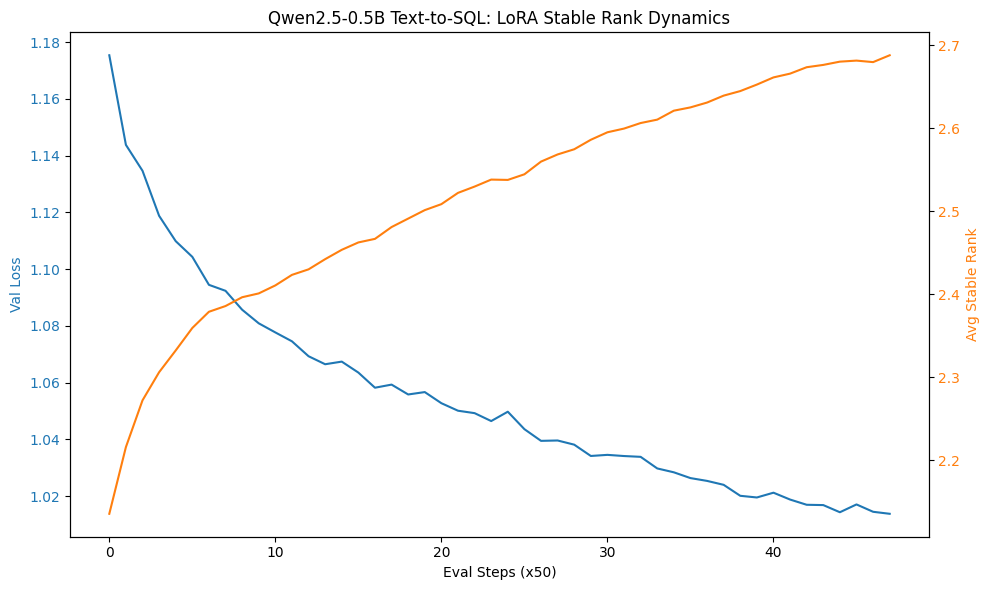

In [6]:
run_experiment(
    model_id="D:\\models\\Qwen2.5-0.5B",
    num_samples=20000,
    lr=2e-4,
    epochs=1,
    batch_size=8,
    rank=4,
    target_suffixes=["gate_proj", "up_proj", "down_proj"],
    report_to=None,
    eval_steps=50
)

Device: cuda
Injecting LoRA for targets ending in: ['gate_proj', 'up_proj', 'down_proj']
Successfully replaced 72 layers with LoRA.
Starting SQL Finetuning...


Epoch 1: 100%|██████████| 2438/2438 [20:17<00:00,  2.00it/s, Val Loss=0.989, Avg SR=3.87]  


Final Average Stable Rank: 3.867


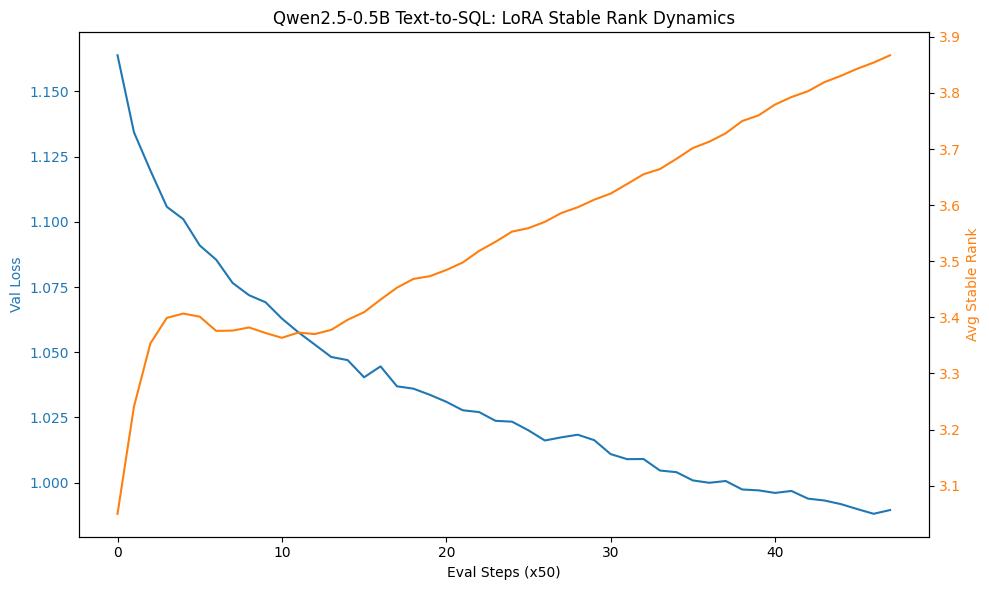

In [7]:
run_experiment(
    model_id="D:\\models\\Qwen2.5-0.5B",
    num_samples=20000,
    lr=2e-4,
    epochs=1,
    batch_size=8,
    rank=16,
    target_suffixes=["gate_proj", "up_proj", "down_proj"],
    report_to=None,
    eval_steps=50
)

Device: cuda
Injecting LoRA for targets ending in: ['gate_proj', 'up_proj', 'down_proj']
Successfully replaced 72 layers with LoRA.
Starting SQL Finetuning...


Epoch 1: 100%|██████████| 2438/2438 [21:03<00:00,  1.93it/s, Val Loss=0.993, Avg SR=3.60]  


Final Average Stable Rank: 3.597


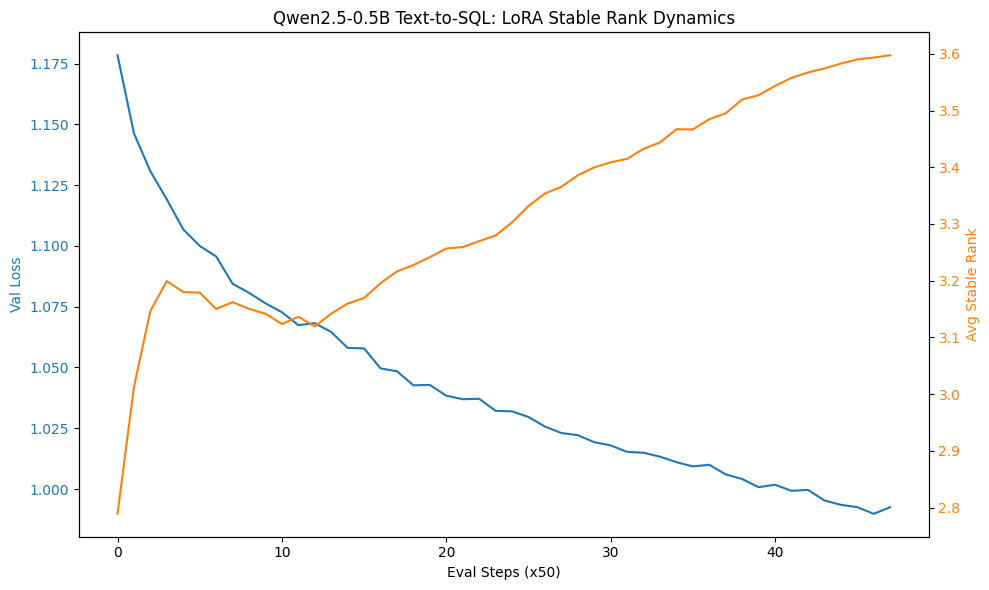

In [8]:
run_experiment(
    model_id="D:\\models\\Qwen2.5-0.5B",
    num_samples=20000,
    lr=2e-4,
    epochs=1,
    batch_size=8,
    rank=64,
    target_suffixes=["gate_proj", "up_proj", "down_proj"],
    report_to=None,
    eval_steps=50
)

Device: cuda
Injecting LoRA for targets ending in: ['gate_proj', 'up_proj', 'down_proj']
Successfully replaced 72 layers with LoRA.
Starting SQL Finetuning...


Epoch 1: 100%|██████████| 2438/2438 [21:43<00:00,  1.87it/s, Val Loss=0.985, Avg SR=2.78]  


Final Average Stable Rank: 2.777


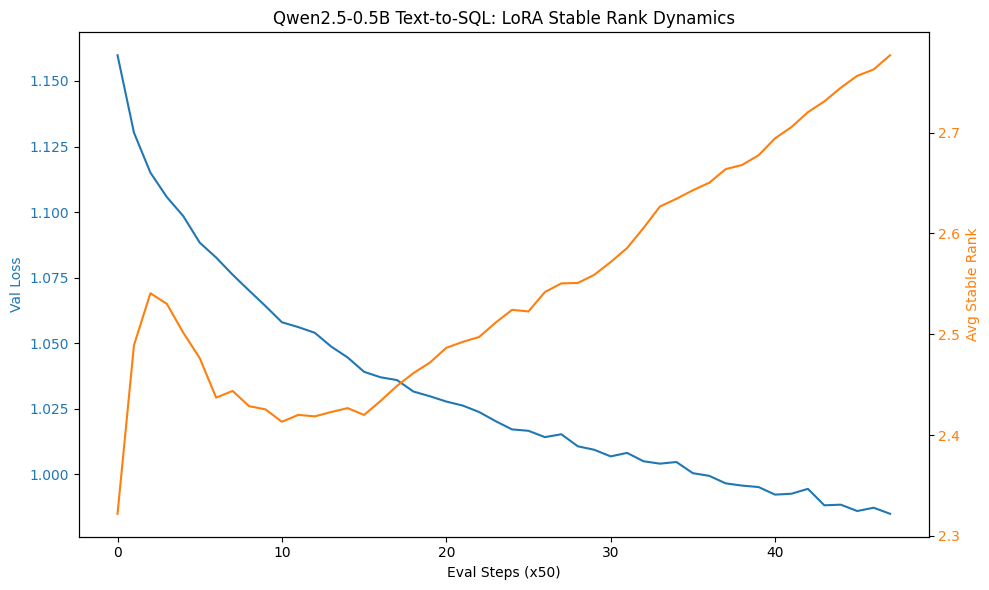

In [10]:
run_experiment(
    model_id="D:\\models\\Qwen2.5-0.5B",
    num_samples=20000,
    lr=2e-4,
    epochs=1,
    batch_size=8,
    rank=256,
    target_suffixes=["gate_proj", "up_proj", "down_proj"],
    report_to=None,
    eval_steps=50
)

Device: cuda
Starting SQL Finetuning...


Epoch 1: 100%|██████████| 4875/4875 [26:14<00:00,  3.10it/s, Val Loss=0.697, Avg SR=0.00]  

Final Average Stable Rank: 0.000


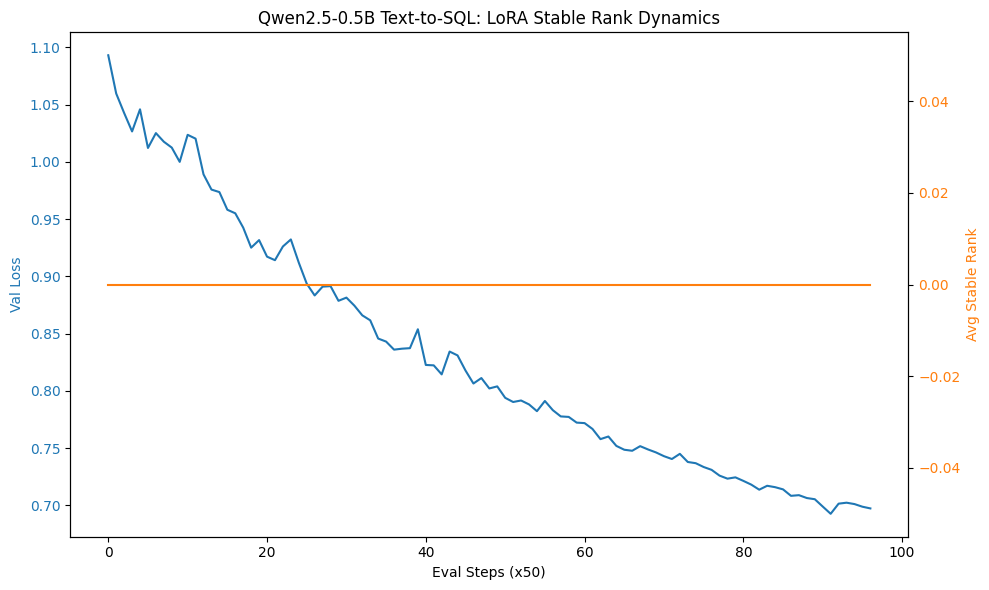

In [ ]:
# full model ft
run_experiment(
    model_id="D:\\models\\Qwen2.5-0.5B",
    num_samples=20000,
    lr=2e-4,
    epochs=1,
    batch_size=4,
    rank=0,
    target_suffixes=[],
    report_to=None,
    eval_steps=50
)